# 3_analise.ipynb: Camada Gold e perguntas de negócio

**Pipeline ETL: Viagens a Serviço (Portal da Transparência, jan-jun/2025)**

Este notebook é a **FASE 3** do pipeline (Arquitetura Medallion):

1. Cria a **camada Gold** no PostgreSQL, agregada com `JOIN` + `GROUP BY`, **como tabela e como VIEW**.
2. Responde às **7 perguntas de negócio**. Cada uma traz a consulta SQL, a tabela de resultado, um gráfico (com título, eixos nomeados e legenda) e uma conclusão **calculada a partir dos dados**.
3. Faz uma leitura crítica da qualidade dos dados.

> Pré-requisito: já ter executado `0_criar_banco.sql`, `1_extrair.py` e `2_transformar.py`.

**Regras de negócio adotadas** (documentadas no README):

| Decisão | Regra |
|---|---|
| Viagens analisadas | somente as **realizadas** (`situacao = 'Realizada'`) |
| Custo da viagem (`valor_total`) | diárias + passagens + outros gastos − devolução |
| Duração (`duracao_dias`) | (data_fim − data_inicio) + 1 |
| Destinos (Pergunta 2) | apenas destinos com **100 viagens ou mais**, para a média não ser distorcida por poucos casos |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from banco import conectar

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PASTA_IMAGENS = Path("imagens")
PASTA_IMAGENS.mkdir(exist_ok=True)

# Paleta: um único tom de azul (magnitude) + cinza para o contexto
COR_DESTAQUE = "#2a78d6"   # barras que respondem à pergunta
COR_CONTEXTO = "#b7d3f6"   # demais barras (contexto)
COR_TEXTO = "#52514e"

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelcolor": COR_TEXTO,
    "xtick.color": COR_TEXTO,
    "ytick.color": COR_TEXTO,
    "axes.grid": True,
    "axes.grid.axis": "x",
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
})

conexao = conectar()


def consultar(sql):
    """Executa um SELECT e devolve um DataFrame."""
    cursor = conexao.cursor()
    cursor.execute(sql)
    colunas = [desc[0] for desc in cursor.description]
    df = pd.DataFrame(cursor.fetchall(), columns=colunas)
    cursor.close()
    # DECIMAL chega como Decimal: converte para float para calcular/plotar
    for coluna in df.columns:
        if df[coluna].map(type).astype(str).str.contains("Decimal").any():
            df[coluna] = df[coluna].astype(float)
    return df


def executar_sql(sql):
    cursor = conexao.cursor()
    cursor.execute(sql)
    conexao.commit()
    cursor.close()


def brl(valor):
    """1234567.8 -> 'R$ 1.234.567,80'"""
    texto = f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {texto}"


def num(valor, casas=0):
    """1234567 -> '1.234.567'"""
    texto = f"{valor:,.{casas}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


def pct(valor):
    """0.123 -> '12,3%'"""
    return f"{valor * 100:.1f}%".replace(".", ",")


def barras_horizontais(rotulos, valores, titulo, eixo_x, eixo_y, legenda,
                       arquivo, destacar=1, formato=None, legenda_contexto=None):
    """
    Gráfico de barras horizontais completo: título, eixos nomeados e legenda.
    As 'destacar' primeiras barras (a resposta) ficam em azul forte.
    """
    rotulos = [str(r) if len(str(r)) <= 45 else str(r)[:42] + "..." for r in rotulos]
    fig, ax = plt.subplots()
    cores = [COR_DESTAQUE if i < destacar else COR_CONTEXTO for i in range(len(valores))]
    ax.barh(rotulos, valores, color=cores, height=0.6)
    ax.invert_yaxis()  # maior valor no topo

    # legenda explícita: o que cada cor significa
    from matplotlib.patches import Patch
    itens = [Patch(color=COR_DESTAQUE, label=legenda)]
    if destacar < len(valores):
        itens.append(Patch(color=COR_CONTEXTO, label=legenda_contexto or "Demais (contexto)"))
    ax.legend(handles=itens, loc="upper left", bbox_to_anchor=(1.01, 1),
              frameon=False)

    ax.set_title(titulo, loc="left")
    ax.set_xlabel(eixo_x)
    ax.set_ylabel(eixo_y)
    ax.set_xlim(0, max(valores) * 1.18)  # espaço para o rótulo da resposta
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))
    if formato:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(formato))
        for i, v in enumerate(valores):  # rótulo direto só na resposta
            if i < destacar:
                ax.text(v, i, "  " + formato(v, None), va="center",
                        fontsize=9, color=COR_TEXTO)
    fig.tight_layout()
    fig.savefig(PASTA_IMAGENS / arquivo, bbox_inches="tight")
    plt.show()


mi = lambda v, _: f"R$ {v / 1e6:,.1f} mi".replace(",", "X").replace(".", ",").replace("X", ".")
reais = lambda v, _: brl(v).replace(",00", "")
inteiro = lambda v, _: num(v)
print("Conectado ao banco:", conexao.info.dbname)

Conectado ao banco: transparencia


## 1. Camada Gold: tabela e VIEW com JOIN + GROUP BY

Duas agregações da Gold, cada uma **gravada como tabela** (`CREATE TABLE ... AS`) e **como VIEW** (`CREATE OR REPLACE VIEW`):

| Gold | Junta | Agrupa por | Responde |
|---|---|---|---|
| `gold_pagamento_resumo` / `vw_gold_pagamento_resumo` | `silver_pagamento` ⨝ `silver_viagem` | órgão pagador, tipo de pagamento | Perguntas 4 e 7 |
| `gold_trecho_resumo` / `vw_gold_trecho_resumo` | `silver_trecho` ⨝ `silver_viagem` | meio de transporte, UF de destino | Perguntas 5 e 6 |

- **Tabela:** guarda o resultado no momento da criação. É rápida de consultar, mas precisa ser recriada quando a Silver muda (`DROP TABLE IF EXISTS` antes).
- **VIEW:** guarda só a consulta e acompanha a Silver automaticamente.

O `JOIN` com `silver_viagem` aplica a regra de negócio: entram só os pagamentos e trechos de viagens **realizadas**.

In [2]:
CONSULTA_GOLD_PAGAMENTO = """
    SELECT p.nome_orgao_pagador,
           p.tipo_pagamento,
           COUNT(*)            AS qtd_pagamentos,
           SUM(p.valor)        AS total_pago,
           ROUND(AVG(p.valor), 2) AS media_pagamento
    FROM silver_pagamento p
    JOIN silver_viagem v ON v.id_viagem = p.id_viagem
    WHERE v.situacao = 'Realizada'
    GROUP BY p.nome_orgao_pagador, p.tipo_pagamento
"""

CONSULTA_GOLD_TRECHO = """
    SELECT t.meio_transporte,
           t.destino_uf,
           COUNT(*)                 AS qtd_trechos,
           COUNT(DISTINCT t.id_viagem) AS qtd_viagens,
           SUM(t.numero_diarias)    AS total_diarias
    FROM silver_trecho t
    JOIN silver_viagem v ON v.id_viagem = t.id_viagem
    WHERE v.situacao = 'Realizada'
    GROUP BY t.meio_transporte, t.destino_uf
"""

for nome, consulta in [("pagamento_resumo", CONSULTA_GOLD_PAGAMENTO),
                       ("trecho_resumo", CONSULTA_GOLD_TRECHO)]:
    executar_sql(f"DROP TABLE IF EXISTS gold_{nome}")
    executar_sql(f"CREATE TABLE gold_{nome} AS {consulta}")
    executar_sql(f"CREATE OR REPLACE VIEW vw_gold_{nome} AS {consulta}")

consultar("""
    SELECT 'gold_pagamento_resumo' AS objeto, 'tabela' AS tipo, COUNT(*) AS linhas FROM gold_pagamento_resumo
    UNION ALL SELECT 'vw_gold_pagamento_resumo', 'view', COUNT(*) FROM vw_gold_pagamento_resumo
    UNION ALL SELECT 'gold_trecho_resumo', 'tabela', COUNT(*) FROM gold_trecho_resumo
    UNION ALL SELECT 'vw_gold_trecho_resumo', 'view', COUNT(*) FROM vw_gold_trecho_resumo
""")

,objeto,tipo,linhas
0,gold_pagamento_resumo,tabela,655
1,vw_gold_pagamento_resumo,view,655
2,gold_trecho_resumo,tabela,201
3,vw_gold_trecho_resumo,view,201


In [3]:
# Amostra da Gold de pagamentos (tabela)
consultar("SELECT * FROM gold_pagamento_resumo ORDER BY total_pago DESC LIMIT 5")

,nome_orgao_pagador,tipo_pagamento,qtd_pagamentos,total_pago,media_pagamento
0,Fundo Nacional de Segurança Pública,DIÁRIAS,73446,"265,679,414.38","3,617.34"
1,Sigiloso,DIÁRIAS,72203,"164,370,999.66","2,276.51"
2,Comando da Aeronáutica,DIÁRIAS,31743,"58,996,802.49","1,858.58"
3,Sigiloso,PASSAGEM,19629,"34,720,787.82","1,768.85"
4,Instituto Nacional do Seguro Social,DIÁRIAS,12015,"31,941,884.09","2,658.50"


## 2. Visão geral: o que existe na Silver

In [4]:
visao = consultar("""
    SELECT situacao,
           COUNT(*)          AS viagens,
           SUM(valor_total)  AS custo_total
    FROM silver_viagem
    GROUP BY situacao
    ORDER BY viagens DESC
""")
visao

,situacao,viagens,custo_total
0,Realizada,338476,"1,177,360,252.98"
1,Não realizada,3384,"10,784,478.15"


In [5]:
realizadas = visao.loc[visao["situacao"] == "Realizada", "viagens"].sum()
print(f"Viagens na Silver: {num(visao['viagens'].sum())}")
print(f"Viagens realizadas (base da análise): {num(realizadas)} "
      f"({pct(realizadas / visao['viagens'].sum())})")

Viagens na Silver: 341.860
Viagens realizadas (base da análise): 338.476 (99,0%)


## Pergunta 1: Quais são os 5 órgãos com maior custo total?

Custo total = soma de `valor_total` das viagens realizadas, por **órgão superior** (quem solicita e gasta).

In [6]:
SQL_P1 = """
    SELECT nome_orgao_superior,
           COUNT(*)          AS viagens,
           SUM(valor_total)  AS custo_total
    FROM silver_viagem
    WHERE situacao = 'Realizada'
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
"""
p1 = consultar(SQL_P1)
p1["participacao"] = p1["custo_total"] / p1["custo_total"].sum()
p1.head(5)

,nome_orgao_superior,viagens,custo_total,participacao
0,Ministério da Justiça e Segurança Pública,75324,"485,748,241.43",0.41
1,Ministério da Defesa,61369,"154,595,910.29",0.13
2,Ministério da Educação,64757,"109,759,836.03",0.09
3,Ministério do Meio Ambiente e Mudança do Clima,19291,"49,300,595.26",0.04
4,Ministério da Previdência Social,8129,"40,236,180.79",0.03


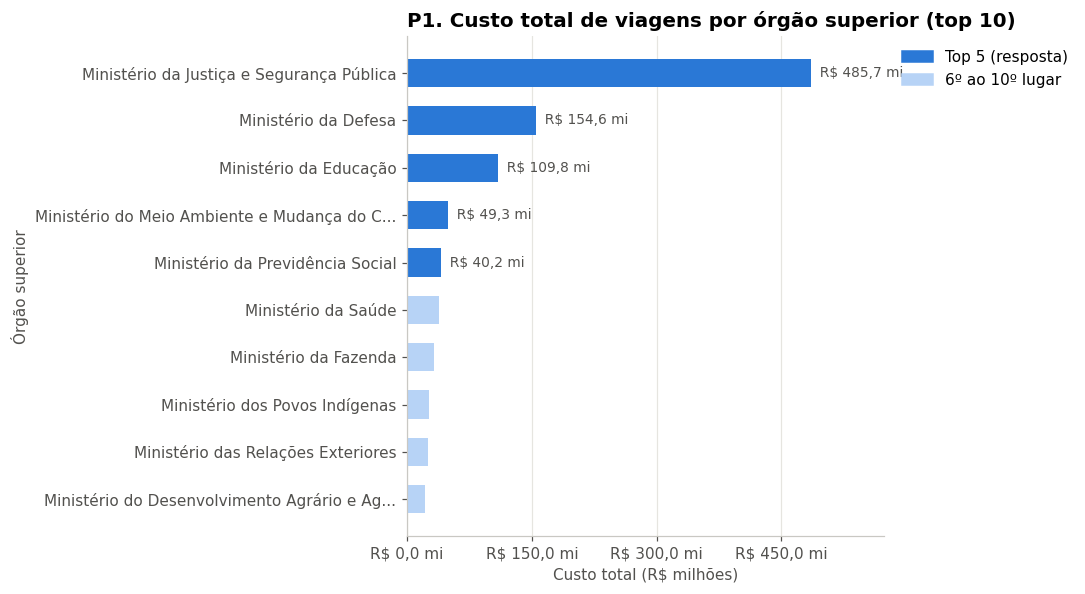

In [7]:
top = p1.head(10)
barras_horizontais(top["nome_orgao_superior"], top["custo_total"],
                   "P1. Custo total de viagens por órgão superior (top 10)",
                   "Custo total (R$ milhões)", "Órgão superior",
                   "Top 5 (resposta)", "p1_orgaos_custo.png", destacar=5,
                   formato=mi, legenda_contexto="6º ao 10º lugar")

In [8]:
top5 = p1.head(5)
print(f"CONCLUSÃO: {top5.iloc[0]['nome_orgao_superior']} lidera com "
      f"{brl(top5.iloc[0]['custo_total'])} ({pct(top5.iloc[0]['participacao'])} do total). "
      f"Os 5 maiores órgãos somam {brl(top5['custo_total'].sum())}, ou seja, "
      f"{pct(top5['participacao'].sum())} de todo o custo de {num(len(p1))} órgãos.")
print("Ranking:", " > ".join(top5["nome_orgao_superior"]))

CONCLUSÃO: Ministério da Justiça e Segurança Pública lidera com R$ 485.748.241,43 (41,3% do total). Os 5 maiores órgãos somam R$ 839.640.763,80, ou seja, 71,3% de todo o custo de 35 órgãos.
Ranking: Ministério da Justiça e Segurança Pública > Ministério da Defesa > Ministério da Educação > Ministério do Meio Ambiente e Mudança do Clima > Ministério da Previdência Social


## Pergunta 2: Quais são os 3 destinos com maior custo médio por viagem?

Destino = campo `destinos` da viagem. Para a média ser representativa, só entram destinos com **100 viagens realizadas ou mais** (`HAVING`).

In [9]:
SQL_P2 = """
    SELECT destinos,
           COUNT(*)                   AS viagens,
           ROUND(AVG(valor_total), 2) AS custo_medio,
           SUM(valor_total)           AS custo_total
    FROM silver_viagem
    WHERE situacao = 'Realizada' AND destinos IS NOT NULL
    GROUP BY destinos
    HAVING COUNT(*) >= 100
    ORDER BY custo_medio DESC
"""
p2 = consultar(SQL_P2)
p2.head(3)

,destinos,viagens,custo_medio,custo_total
0,"Brasília/DF, Brasília/DF",283,"27,401.80","7,754,708.71"
1,Genebra/Suíça,242,"25,469.22","6,163,551.80"
2,Nova York/Estados Unidos da América,149,"21,214.19","3,160,914.64"


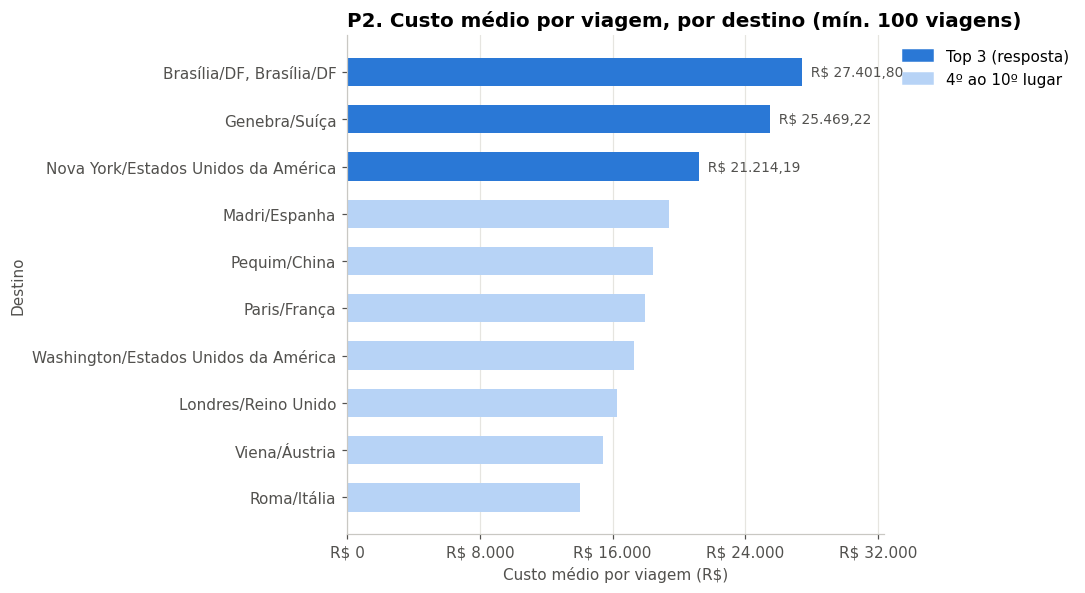

In [10]:
top = p2.head(10)
barras_horizontais(top["destinos"], top["custo_medio"],
                   "P2. Custo médio por viagem, por destino (mín. 100 viagens)",
                   "Custo médio por viagem (R$)", "Destino",
                   "Top 3 (resposta)", "p2_destinos_custo_medio.png", destacar=3,
                   formato=reais, legenda_contexto="4º ao 10º lugar")

In [11]:
media_geral = consultar("SELECT AVG(valor_total) AS m FROM silver_viagem WHERE situacao = 'Realizada'")["m"][0]
linhas = [f"{i + 1}º {r.destinos}: {brl(r.custo_medio)} ({num(r.viagens)} viagens)"
          for i, r in enumerate(p2.head(3).itertuples())]
print("CONCLUSÃO:", " | ".join(linhas))
print(f"O 1º colocado custa {num(p2.iloc[0]['custo_medio'] / media_geral, 1)}x a média geral "
      f"por viagem ({brl(media_geral)}). {num(len(p2))} destinos têm 100+ viagens.")

CONCLUSÃO: 1º Brasília/DF, Brasília/DF: R$ 27.401,80 (283 viagens) | 2º Genebra/Suíça: R$ 25.469,22 (242 viagens) | 3º Nova York/Estados Unidos da América: R$ 21.214,19 (149 viagens)
O 1º colocado custa 7,9x a média geral por viagem (R$ 3.478,42). 349 destinos têm 100+ viagens.


## Pergunta 3: Qual é a viagem de maior duração e o seu custo total?

Duração = `duracao_dias` = (data_fim − data_inicio) + 1. Em caso de empate na duração, vence o maior custo.

In [12]:
SQL_P3 = """
    SELECT id_viagem, nome_orgao_superior, cargo, destinos,
           data_inicio, data_fim, duracao_dias, valor_total
    FROM silver_viagem
    WHERE situacao = 'Realizada' AND duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC, valor_total DESC
    LIMIT 10
"""
p3 = consultar(SQL_P3)
p3.head(1)

,id_viagem,nome_orgao_superior,cargo,destinos,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,TECNICO DO SEGURO SOCIAL,Mogi Mirim/SP,2025-01-13,2026-01-31,384,0.00


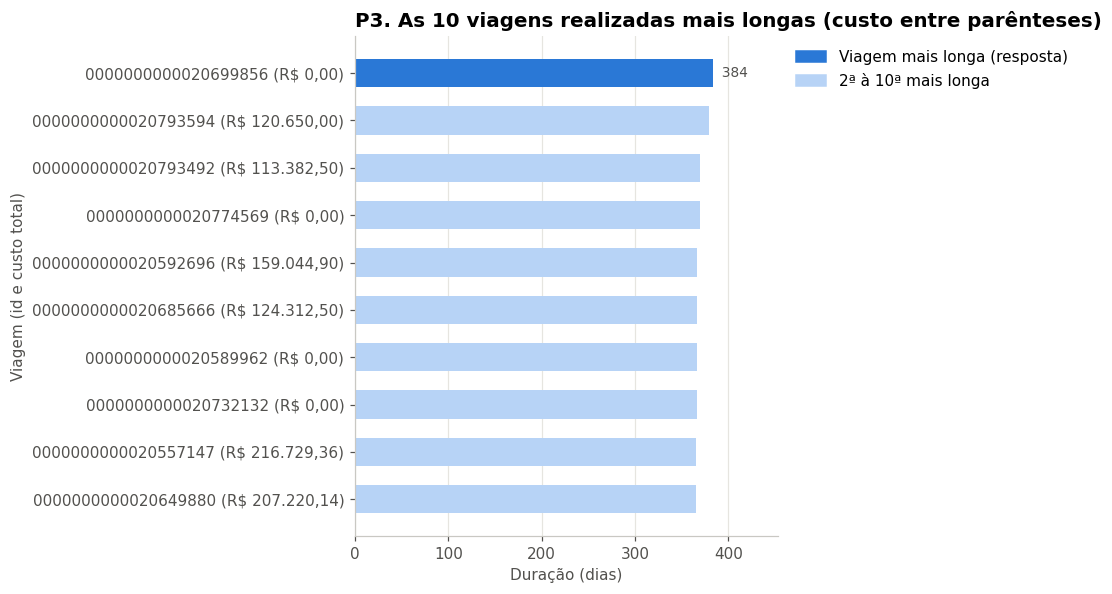

In [13]:
rotulos = [f"{r.id_viagem} ({brl(r.valor_total)})" for r in p3.itertuples()]
barras_horizontais(rotulos, p3["duracao_dias"],
                   "P3. As 10 viagens realizadas mais longas (custo entre parênteses)",
                   "Duração (dias)", "Viagem (id e custo total)",
                   "Viagem mais longa (resposta)", "p3_viagens_mais_longas.png",
                   destacar=1, formato=inteiro, legenda_contexto="2ª à 10ª mais longa")

In [14]:
v = p3.iloc[0]
print(f"CONCLUSÃO: a viagem mais longa é a {v['id_viagem']} ({v['nome_orgao_superior']}), "
      f"com {num(v['duracao_dias'])} dias ({v['data_inicio']:%d/%m/%Y} a {v['data_fim']:%d/%m/%Y}) "
      f"e custo total registrado de {brl(v['valor_total'])}.")
if v["valor_total"] == 0:
    print("ATENÇÃO: custo R$ 0,00 numa viagem tão longa sugere gastos não registrados "
          "ou custeados por outra fonte. Ver a seção de qualidade dos dados.")

CONCLUSÃO: a viagem mais longa é a 0000000000020699856 (Ministério da Previdência Social), com 384 dias (13/01/2025 a 31/01/2026) e custo total registrado de R$ 0,00.
ATENÇÃO: custo R$ 0,00 numa viagem tão longa sugere gastos não registrados ou custeados por outra fonte. Ver a seção de qualidade dos dados.


## Pergunta 4: Qual tipo de pagamento tem o maior valor médio?

Usa a **Gold** `gold_pagamento_resumo`. A média é ponderada, calculada como total pago ÷ quantidade de pagamentos, porque a Gold está agrupada também por órgão.

In [15]:
SQL_P4 = """
    SELECT tipo_pagamento,
           SUM(qtd_pagamentos)                                AS qtd_pagamentos,
           SUM(total_pago)                                    AS total_pago,
           ROUND(SUM(total_pago) / SUM(qtd_pagamentos), 2)    AS valor_medio
    FROM gold_pagamento_resumo
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
"""
p4 = consultar(SQL_P4)
p4

,tipo_pagamento,qtd_pagamentos,total_pago,valor_medio
0,DIÁRIAS,"400,364.00","832,271,736.62","2,078.79"
1,PASSAGEM,"182,883.00","344,243,893.31","1,882.32"
2,Serviço correlato: seguro,"4,789.00","2,141,913.28",447.26
3,RESTITUIÇÃO,"11,574.00","2,843,762.01",245.70


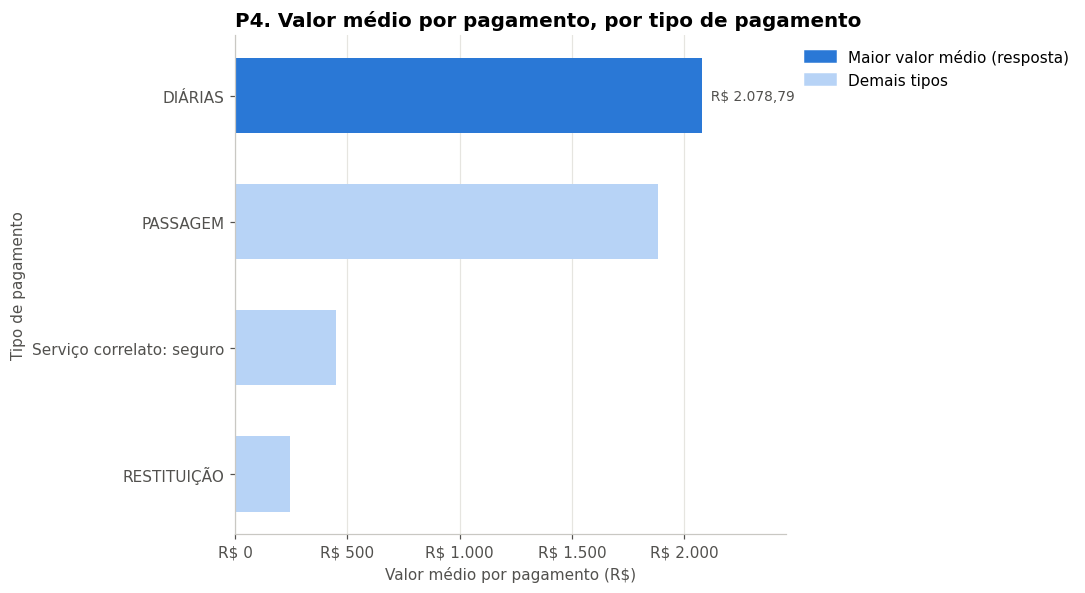

In [16]:
barras_horizontais(p4["tipo_pagamento"], p4["valor_medio"],
                   "P4. Valor médio por pagamento, por tipo de pagamento",
                   "Valor médio por pagamento (R$)", "Tipo de pagamento",
                   "Maior valor médio (resposta)", "p4_tipo_pagamento_medio.png",
                   destacar=1, formato=reais, legenda_contexto="Demais tipos")

In [17]:
a, b = p4.iloc[0], p4.iloc[1]
print(f"CONCLUSÃO: '{a['tipo_pagamento']}' tem o maior valor médio: {brl(a['valor_medio'])} "
      f"por pagamento ({num(a['qtd_pagamentos'])} pagamentos). É "
      f"{num(a['valor_medio'] / b['valor_medio'], 1)}x o 2º colocado ('{b['tipo_pagamento']}', "
      f"{brl(b['valor_medio'])}).")

CONCLUSÃO: 'DIÁRIAS' tem o maior valor médio: R$ 2.078,79 por pagamento (400.364 pagamentos). É 1,1x o 2º colocado ('PASSAGEM', R$ 1.882,32).


## Pergunta 5: Qual meio de transporte é o mais usado nos trechos?

Usa a **Gold** `gold_trecho_resumo` e conta trechos por meio de transporte.

In [18]:
SQL_P5 = """
    SELECT COALESCE(meio_transporte, 'Não informado') AS meio_transporte,
           SUM(qtd_trechos) AS qtd_trechos
    FROM gold_trecho_resumo
    GROUP BY COALESCE(meio_transporte, 'Não informado')
    ORDER BY qtd_trechos DESC
"""
p5 = consultar(SQL_P5)
p5["participacao"] = p5["qtd_trechos"] / p5["qtd_trechos"].sum()
p5

,meio_transporte,qtd_trechos,participacao
0,Veículo Oficial,"385,734.00",0.51
1,Aéreo,"226,707.00",0.30
2,Rodoviário,"64,454.00",0.09
3,Veículo Próprio,"42,736.00",0.06
4,Inválido,"26,523.00",0.04
5,Fluvial,"8,392.00",0.01
6,Ferroviário,868.00,0.00
7,Marítimo,471.00,0.00


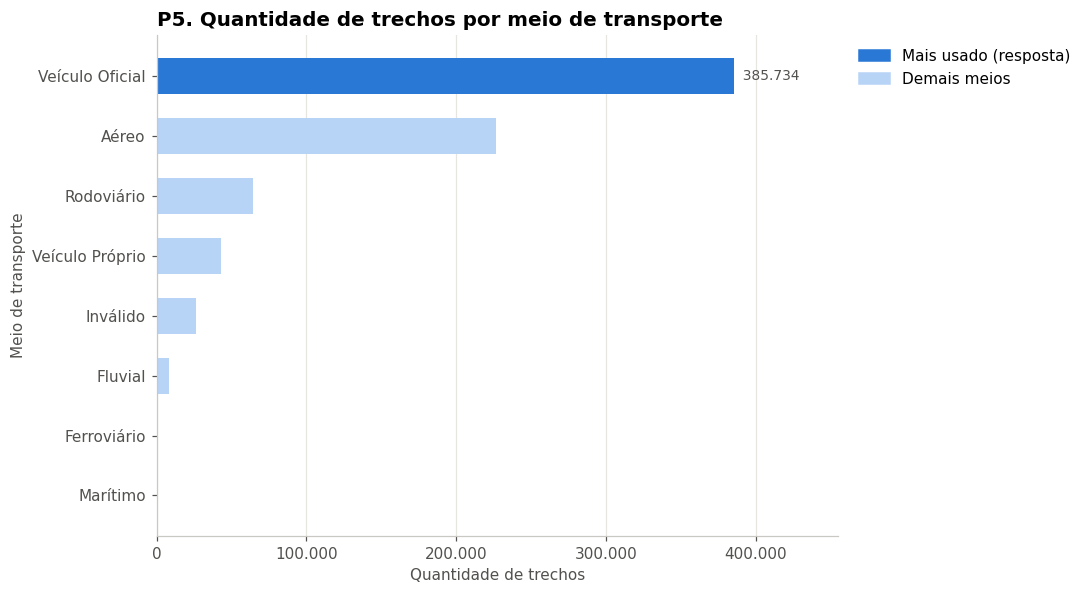

In [19]:
barras_horizontais(p5["meio_transporte"], p5["qtd_trechos"],
                   "P5. Quantidade de trechos por meio de transporte",
                   "Quantidade de trechos", "Meio de transporte",
                   "Mais usado (resposta)", "p5_meio_transporte.png",
                   destacar=1, formato=inteiro, legenda_contexto="Demais meios")

In [20]:
m = p5.iloc[0]
print(f"CONCLUSÃO: '{m['meio_transporte']}' é o meio mais usado: {num(m['qtd_trechos'])} "
      f"trechos ({pct(m['participacao'])} do total de {num(p5['qtd_trechos'].sum())}). "
      f"O 2º é '{p5.iloc[1]['meio_transporte']}' ({pct(p5.iloc[1]['participacao'])}).")

CONCLUSÃO: 'Veículo Oficial' é o meio mais usado: 385.734 trechos (51,0% do total de 755.885). O 2º é 'Aéreo' (30,0%).


## Pergunta 6: Qual UF de destino aparece em mais trechos?

Usa a **Gold** `gold_trecho_resumo` e conta trechos por UF de destino.

In [21]:
SQL_P6 = """
    SELECT COALESCE(destino_uf, 'Não informado') AS destino_uf,
           SUM(qtd_trechos) AS qtd_trechos
    FROM gold_trecho_resumo
    GROUP BY COALESCE(destino_uf, 'Não informado')
    ORDER BY qtd_trechos DESC
"""
p6 = consultar(SQL_P6)
p6["participacao"] = p6["qtd_trechos"] / p6["qtd_trechos"].sum()
p6.head(10)

,destino_uf,qtd_trechos,participacao
0,São Paulo,"81,727.00",0.11
1,Distrito Federal,"77,962.00",0.10
2,Minas Gerais,"50,555.00",0.07
3,Rio de Janeiro,"43,481.00",0.06
4,Paraná,"42,323.00",0.06
5,Pará,"39,742.00",0.05
6,Rio Grande do Sul,"38,397.00",0.05
7,Mato Grosso do Sul,"30,450.00",0.04
8,Bahia,"28,141.00",0.04
9,Pernambuco,"28,117.00",0.04


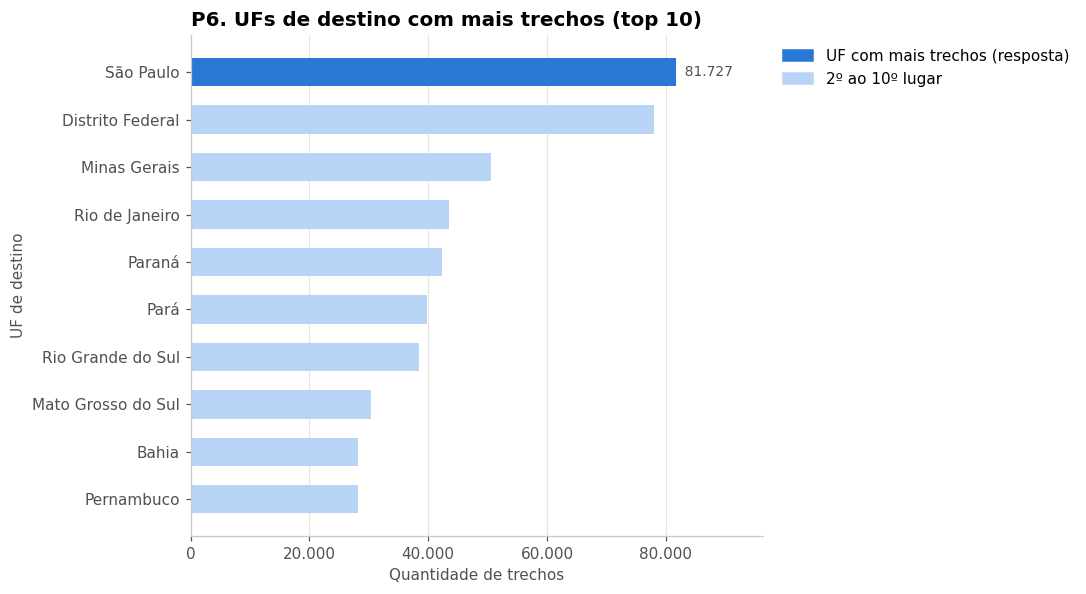

In [22]:
top = p6.head(10)
barras_horizontais(top["destino_uf"], top["qtd_trechos"],
                   "P6. UFs de destino com mais trechos (top 10)",
                   "Quantidade de trechos", "UF de destino",
                   "UF com mais trechos (resposta)", "p6_uf_destino.png",
                   destacar=1, formato=inteiro, legenda_contexto="2º ao 10º lugar")

In [23]:
u = p6.iloc[0]
print(f"CONCLUSÃO: {u['destino_uf']} é a UF de destino com mais trechos: {num(u['qtd_trechos'])} "
      f"({pct(u['participacao'])}). As 3 primeiras ({', '.join(p6.head(3)['destino_uf'])}) "
      f"concentram {pct(p6.head(3)['participacao'].sum())} dos trechos.")

CONCLUSÃO: São Paulo é a UF de destino com mais trechos: 81.727 (10,8%). As 3 primeiras (São Paulo, Distrito Federal, Minas Gerais) concentram 27,8% dos trechos.


## Pergunta 7: Qual órgão pagou mais no total?

Usa a **Gold** `gold_pagamento_resumo`, somando por **órgão pagador**. O órgão pagador é quem efetivamente desembolsa, e pode ser diferente do órgão superior da Pergunta 1.

In [24]:
SQL_P7 = """
    SELECT nome_orgao_pagador,
           SUM(qtd_pagamentos) AS qtd_pagamentos,
           SUM(total_pago)     AS total_pago
    FROM gold_pagamento_resumo
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
"""
p7 = consultar(SQL_P7)
p7["participacao"] = p7["total_pago"] / p7["total_pago"].sum()
p7.head(5)

,nome_orgao_pagador,qtd_pagamentos,total_pago,participacao
0,Fundo Nacional de Segurança Pública,"79,715.00","278,288,685.42",0.24
1,Sigiloso,"92,452.00","199,308,482.09",0.17
2,Comando da Aeronáutica,"45,807.00","81,069,602.67",0.07
3,Instituto Nacional do Seguro Social,"18,224.00","37,254,697.89",0.03
4,Comando do Exército,"22,607.00","36,576,135.70",0.03


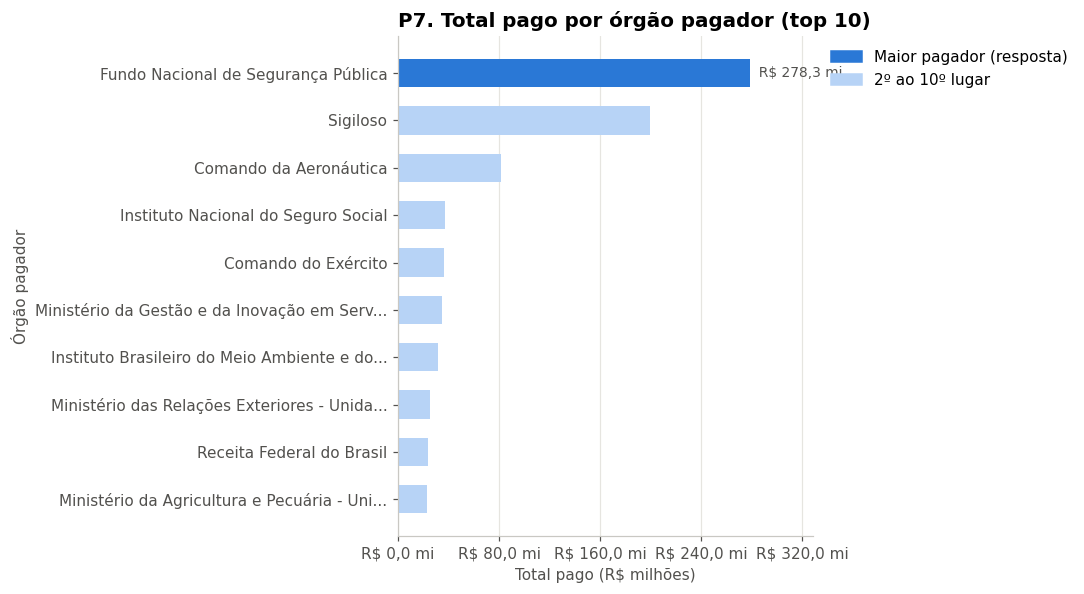

In [25]:
top = p7.head(10)
barras_horizontais(top["nome_orgao_pagador"], top["total_pago"],
                   "P7. Total pago por órgão pagador (top 10)",
                   "Total pago (R$ milhões)", "Órgão pagador",
                   "Maior pagador (resposta)", "p7_orgao_pagador.png",
                   destacar=1, formato=mi, legenda_contexto="2º ao 10º lugar")

In [26]:
o = p7.iloc[0]
print(f"CONCLUSÃO: {o['nome_orgao_pagador']} foi quem mais pagou: {brl(o['total_pago'])} "
      f"({pct(o['participacao'])} do total pago, em {num(o['qtd_pagamentos'])} pagamentos).")
if o["nome_orgao_pagador"] != p1.iloc[0]["nome_orgao_superior"]:
    print(f"Quem mais GASTA (P1: {p1.iloc[0]['nome_orgao_superior']}) não é quem mais PAGA "
          f"(P7: {o['nome_orgao_pagador']}): o gasto é do órgão superior, mas o desembolso "
          f"sai de fundos e unidades pagadoras específicas.")

CONCLUSÃO: Fundo Nacional de Segurança Pública foi quem mais pagou: R$ 278.288.685,42 (23,6% do total pago, em 79.715 pagamentos).
Quem mais GASTA (P1: Ministério da Justiça e Segurança Pública) não é quem mais PAGA (P7: Fundo Nacional de Segurança Pública): o gasto é do órgão superior, mas o desembolso sai de fundos e unidades pagadoras específicas.


## 3. Leitura crítica: qualidade dos dados

Ler os resultados com espírito crítico também é análise. Os números abaixo são calculados direto do banco.

In [27]:
qualidade = consultar("""
    SELECT
      (SELECT COUNT(*) FROM silver_viagem WHERE situacao = 'Realizada' AND valor_total = 0)
          AS viagens_custo_zero,
      (SELECT COUNT(*) FROM silver_viagem WHERE situacao = 'Realizada' AND valor_total < 0)
          AS viagens_custo_negativo,
      (SELECT COUNT(*) FROM silver_viagem WHERE situacao = 'Realizada' AND data_fim > DATE '2025-06-30')
          AS viagens_terminam_apos_junho,
      (SELECT COUNT(*) FROM silver_viagem WHERE data_fim < data_inicio)
          AS viagens_fim_antes_inicio,
      (SELECT COUNT(*) FROM silver_passagem WHERE data_emissao IS NULL)
          AS passagens_sem_data_emissao,
      (SELECT COUNT(*) FROM silver_trecho WHERE meio_transporte ILIKE 'inv%lido')
          AS trechos_meio_invalido,
      (SELECT COUNT(*) FROM silver_pagamento WHERE nome_orgao_pagador ILIKE 'sigilos%')
          AS pagamentos_sigilosos
""").T.rename(columns={0: "quantidade"})
qualidade

,quantidade
viagens_custo_zero,18545
viagens_custo_negativo,3
viagens_terminam_apos_junho,13630
viagens_fim_antes_inicio,0
passagens_sem_data_emissao,664
trechos_meio_invalido,26659
pagamentos_sigilosos,93141


In [28]:
q = qualidade["quantidade"]
print(f"- {num(q['viagens_custo_zero'])} viagens realizadas têm custo R$ 0,00 "
      f"({pct(q['viagens_custo_zero'] / realizadas)} das realizadas).")
print(f"- {num(q['viagens_custo_negativo'])} viagens têm custo negativo (devolução maior que os gastos).")
print(f"- {num(q['viagens_terminam_apos_junho'])} viagens terminam depois de junho: o arquivo traz as "
      f"viagens INICIADAS no semestre.")
print(f"- {num(q['passagens_sem_data_emissao'])} passagens sem data de emissão viraram NULL na Silver.")
print(f"- {num(q['trechos_meio_invalido'])} trechos com meio de transporte 'Inválido' e "
      f"{num(q['pagamentos_sigilosos'])} pagamentos de órgão 'Sigiloso' limitam a análise.")

- 18.545 viagens realizadas têm custo R$ 0,00 (5,5% das realizadas).
- 3 viagens têm custo negativo (devolução maior que os gastos).
- 13.630 viagens terminam depois de junho: o arquivo traz as viagens INICIADAS no semestre.
- 664 passagens sem data de emissão viraram NULL na Silver.
- 26.659 trechos com meio de transporte 'Inválido' e 93.141 pagamentos de órgão 'Sigiloso' limitam a análise.


## 4. Resumo das respostas

A tabela é montada a partir dos resultados acima, então é atualizada sempre que o pipeline roda de novo.

In [29]:
resumo = pd.DataFrame([
    (1, "5 órgãos com maior custo total",
     "; ".join(f"{r.nome_orgao_superior} ({brl(r.custo_total)})" for r in p1.head(5).itertuples())),
    (2, "3 destinos com maior custo médio",
     "; ".join(f"{r.destinos} ({brl(r.custo_medio)})" for r in p2.head(3).itertuples())),
    (3, "Viagem de maior duração e custo",
     f"{p3.iloc[0]['id_viagem']}: {num(p3.iloc[0]['duracao_dias'])} dias, {brl(p3.iloc[0]['valor_total'])}"),
    (4, "Tipo de pagamento com maior valor médio",
     f"{p4.iloc[0]['tipo_pagamento']} ({brl(p4.iloc[0]['valor_medio'])})"),
    (5, "Meio de transporte mais usado",
     f"{p5.iloc[0]['meio_transporte']} ({num(p5.iloc[0]['qtd_trechos'])} trechos, {pct(p5.iloc[0]['participacao'])})"),
    (6, "UF de destino com mais trechos",
     f"{p6.iloc[0]['destino_uf']} ({num(p6.iloc[0]['qtd_trechos'])} trechos)"),
    (7, "Órgão que mais pagou",
     f"{p7.iloc[0]['nome_orgao_pagador']} ({brl(p7.iloc[0]['total_pago'])})"),
], columns=["nº", "pergunta", "resposta"])
resumo.style.hide(axis="index")

nº,pergunta,resposta
1,5 órgãos com maior custo total,"Ministério da Justiça e Segurança Pública (R$ 485.748.241,43); Ministério da Defesa (R$ 154.595.910,29); Ministério da Educação (R$ 109.759.836,03); Ministério do Meio Ambiente e Mudança do Clima (R$ 49.300.595,26); Ministério da Previdência Social (R$ 40.236.180,79)"
2,3 destinos com maior custo médio,"Brasília/DF, Brasília/DF (R$ 27.401,80); Genebra/Suíça (R$ 25.469,22); Nova York/Estados Unidos da América (R$ 21.214,19)"
3,Viagem de maior duração e custo,"0000000000020699856: 384 dias, R$ 0,00"
4,Tipo de pagamento com maior valor médio,"DIÁRIAS (R$ 2.078,79)"
5,Meio de transporte mais usado,"Veículo Oficial (385.734 trechos, 51,0%)"
6,UF de destino com mais trechos,São Paulo (81.727 trechos)
7,Órgão que mais pagou,"Fundo Nacional de Segurança Pública (R$ 278.288.685,42)"


In [30]:
conexao.close()
print("Conexão encerrada. Gráficos salvos em:", PASTA_IMAGENS.resolve())

Conexão encerrada. Gráficos salvos em: /content/pipeline-etl-viagens/imagens
